# 0. Carga de librerías

In [1]:
# Core TensorFlow and Keras imports
import tensorflow as tf
from tensorflow import keras
from collections import Counter

# Keras layers and models
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import (
    ReduceLROnPlateau,
    EarlyStopping)

# Keras para transfer learning

# MobileNet
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as MobileNetV2Preprocess

# ResNet50
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as ResNet50Preprocess

#--------------------------------------------------------------------------------

from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import array_to_img
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.layers import (
    Dense, 
    Flatten, 
    Conv2D, 
    MaxPooling2D, 
    Dropout,
    BatchNormalization,
    Input
)

# Keras utilities
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

# Data processing and visualization
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import numpy as np
import matplotlib.pyplot as plt

# Actividad Deep Vision

Diseñar y comparar dos estrategias para la clasificación de imágenes en el dataset CIFAR100 de Keras (https://keras.io/api/datasets/cifar100/)

### **Estrategia 1: Red pre-entrenada**

La primera estrategia a comparar debe incluir la utilización de redes preentrenadas con el dataset ImageNet, llevando a cabo tareas de *transfer learning* y *fine-tuning* para clasificar los objetos de CIFAR100. Deben compararse al menos dos tipos de arquitecturas (VGGs, ResNet50, Xception, InceptionV3, InceptionResNetV2, MobileNetV2, DenseNet, ResNet...) y se debe seleccionar la que mayor precisión nos dé (información sobre las arquitecturas disponibles en https://keras.io/applications/). Se espera que el ejercicio presente una profunda experimentación haciendo uso todas las técnicas de optimización mostradas en clase de forma justificada para la mejora del rendimiento de la red neuronal (weight regularization, dropout, batch normalization, data augmentation, etc.).

### **Estrategia 2: Entrenar desde cero o from scratch**

La segunda estrategia a comparar será una red neuronal que se debe diseñar, entrenar y optimizar. Se requiere una justificación empírica de las decisiones que llevaron a la selección de atributos, capas e hiperparámetros a los que se ha llegado. Se espera que el ejercicio presente una profunda experimentación haciendo uso de todas las técnicas de optimización mostradas en clase de forma justificada para la mejora del rendimiento de la red neuronal (weight regularization, dropout, batch normalization, data augmentation...).

## Normas a seguir

- Se debe entregar un **ÚNICO GOOGLE COLAB notebook** (archivo .ipynb) que incluya las instrucciones presentes y su **EJECUCIÓN!!!**. Debe aparecer todo el proceso seguido (carga de datos, visualización de datos, proceso de entrenamiento y proceso de validación del modelo).
- Poner el nombre del grupo en el nombre del archivo y el nombre de todos los integrantes del grupo al inicio del notebook.
- Las redes utilizadas deben estar entrenadas y con las métricas extraídas en el conjunto de test.
- Es recomendable crear una última sección de texto en el notebook en la que se discutan los diferentes modelos obtenidos y se extraigan las conclusiones pertinentes.

## Criterio de evaluación

- Seguimiento de las normas establecidas en la actividad.
- Efectividad al presentar las comparaciones entre métricas de evaluación de ambos modelos.
- Demostración de la utilización de técnicas de optimización para mejorar el rendimiento de los modelos.
- Modelos predictivos con rendimiento superior al aleatorio.
- Corrección en el uso de algoritmos, modelos y formas idiomáticas en Python.
- El código debe poder ejecutarse sin modificación alguna en Google Colaboratory.


# 1. Carga de datos

In [2]:
# Carga de datos
print("[INFO]: Loading CIFAR-100 data...")
((x_train, y_train), (x_test, y_test)) = cifar100.load_data()

# CIFAR100 labelnames
labelNames = ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm']

[INFO]: Loading CIFAR-100 data...


In [3]:
print(f"Training data shape x_train: {x_train.shape}")
print(f"Testing data shape x_test: {x_test.shape}")
print(f"Testing data shape y_train: {y_train.shape}")
print(f"Testing data shape y_test: {y_test.shape}")
print(f"Number of classes: {len(labelNames)}")

Training data shape x_train: (50000, 32, 32, 3)
Testing data shape x_test: (10000, 32, 32, 3)
Testing data shape y_train: (50000, 1)
Testing data shape y_test: (10000, 1)
Number of classes: 100


Revisamos la carga de los datos con una carga aleatoria de 9 imagenes del dataset y sus etiquetas.

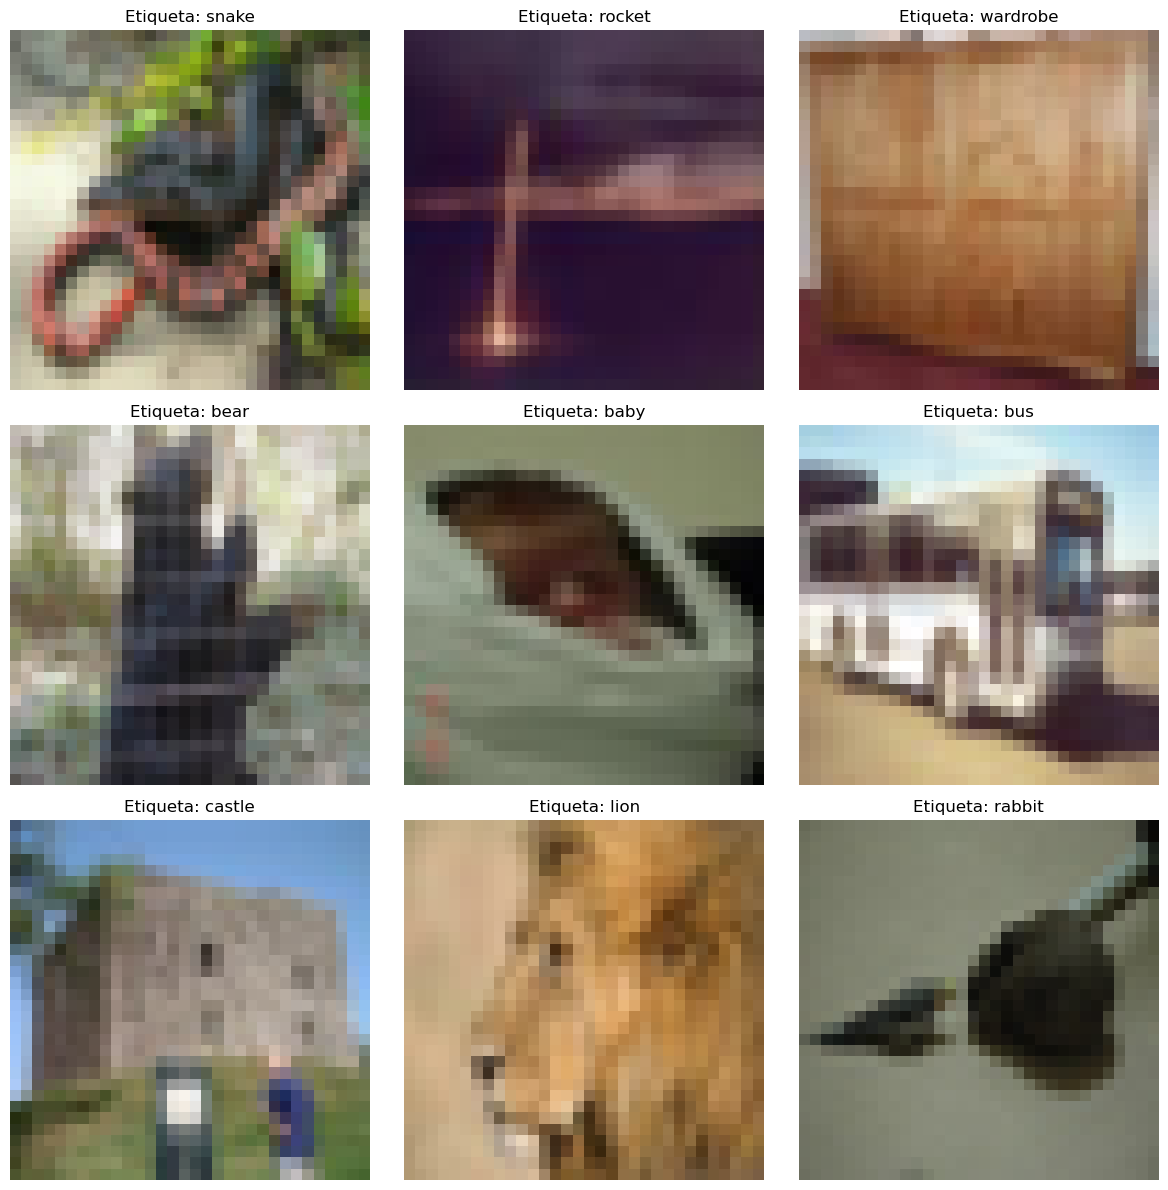

In [4]:
# Selecciona 9 índices aleatorios del conjunto de entrenamiento
indices_aleatorios = np.random.choice(len(x_train), 9, replace=False)

# Configurar la figura para 3x3 imágenes
plt.figure(figsize=(12, 12))

for i, index in enumerate(indices_aleatorios):
    # Obtener la imagen y su etiqueta
    image = x_train[index]
    label_index = y_train[index][0]  # Obtener el índice de la clase
    label_name = labelNames[label_index]  # Obtener el nombre de la clase correspondiente
    
    # Crear una subgráfica (3x3)
    plt.subplot(3, 3, i+1)  
    plt.imshow(image)
    plt.title(f"Etiqueta: {label_name}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# 1.1 Data augmentation

Para cada uno de los modelos a probar, se crea un data augmetation personalizado, ya que según el problema y los recursos, es necesaria una transformación de las imágenes más agresiva, en total son tres, una para el modelo MobileNetV2, una para el modelo ResNet50 y otra para el modelo creado desde 0.

Cada transformación, va con su gráfica de prueba para ver el resultado.

### 1.1.1. Data augmentation modelo MobileNet

In [5]:
datagenMobileNet = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.3,
    horizontal_flip=True,
    vertical_flip = True,

    validation_split=0.2,
)

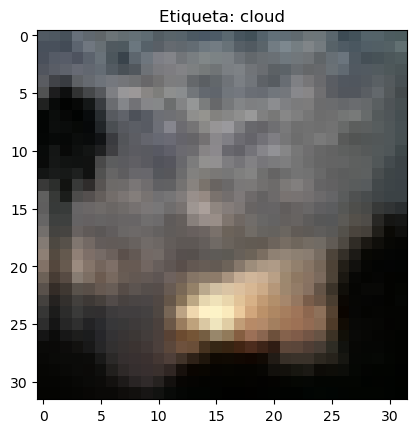

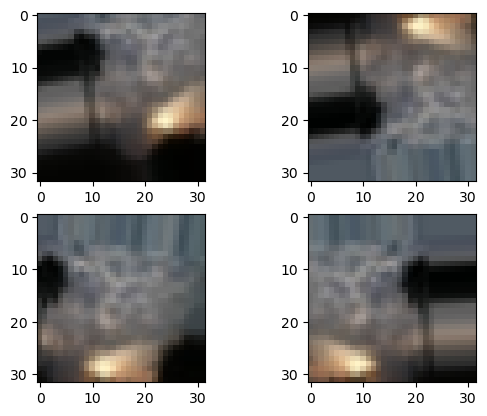

In [6]:
sample = np.random.choice(x_train.shape[0])
label_sample = labelNames[y_train[sample, 0]]



plt.imshow(x_train[sample])
plt.title(f"Etiqueta: {label_sample}")
plt.show()

fig, axes = plt.subplots(2,2)
i = 0
for batch in datagenMobileNet.flow(x_train[sample].reshape((1,32,32,3)), batch_size=1):
    axes[i//2, i%2].imshow(array_to_img(batch[0]))
    i += 1
    if i == 4:
        break
plt.show()

### 1.1.2. Data augmentation modelo ResNet50

In [7]:
datagenResNet50 = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,

    validation_split=0.2,
)

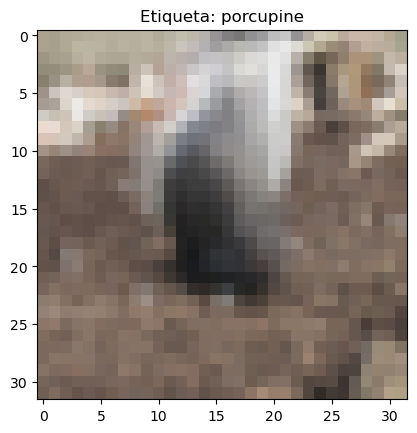

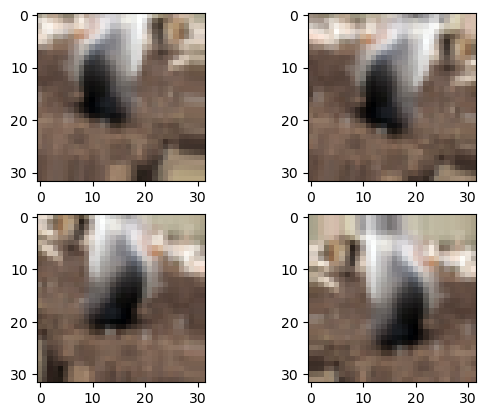

In [8]:
sample = np.random.choice(x_train.shape[0])
label_sample = labelNames[y_train[sample, 0]]



plt.imshow(x_train[sample])
plt.title(f"Etiqueta: {label_sample}")
plt.show()

fig, axes = plt.subplots(2,2)
i = 0
for batch in datagenResNet50.flow(x_train[sample].reshape((1,32,32,3)), batch_size=1):
    axes[i//2, i%2].imshow(array_to_img(batch[0]))
    i += 1
    if i == 4:
        break
plt.show()

### 1.1.3. Data agumentation modelo base

Originalmente, no se recurrió a técnicas de Data augmentation, pero la red no daba un accuracy superior al 50%, para poder aumentar la complejidad de la red sin recurrir a un sobreajuste, se añade un data augmentation ligero que haga las imágenes más complicadas de reconocer.

In [9]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,

    validation_split=0.2,
)

Seleccionamos una imagen de ejemplo y su etiqueta, vamos a crear un data augmentation sobre dichas imagenes para mejorar el rendimiento del modelo.

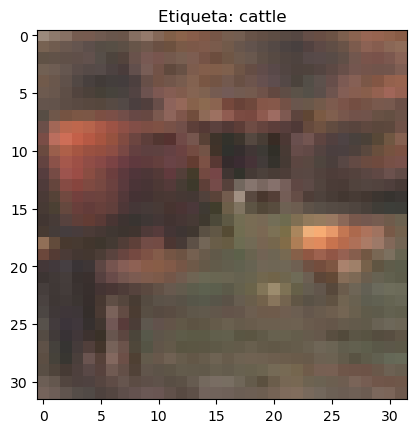

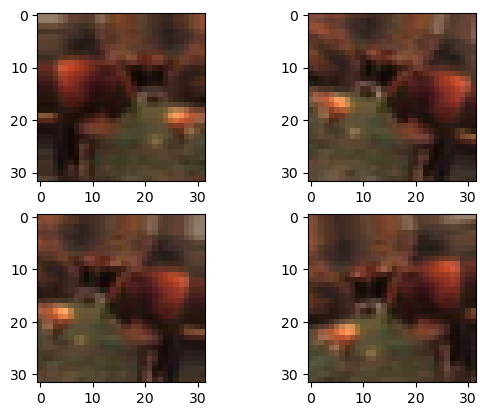

In [10]:
sample = np.random.choice(x_train.shape[0])
label_sample = labelNames[y_train[sample, 0]]



plt.imshow(x_train[sample])
plt.title(f"Etiqueta: {label_sample}")
plt.show()

fig, axes = plt.subplots(2,2)
i = 0
for batch in datagen.flow(x_train[sample].reshape((1,32,32,3)), batch_size=1):
    axes[i//2, i%2].imshow(array_to_img(batch[0]))
    i += 1
    if i == 4:
        break
plt.show()

Introducimos el data augmentation en este apartado, ya que se puede aplicar a todos los modelos y la creación del objeto datagen es independiente al resto del código, se puede hacer pruebas añadiendo o no el objeto a la hora de entrenar el modelo para comprobar su eficacia a la hora realizar las pruebas con cada modelo.

# 2. Preprocesamiento de imagenes

En primer lugar y para todos los modelos, se convierten las etiquetas a one hot econding para mejorar el procesamiento del modelo.

In [11]:
y_train = tf.keras.utils.to_categorical(y_train, 100)
y_test = tf.keras.utils.to_categorical(y_test, 100)

# 2.1. Preprocesamiento para transfer learning - fine tunning

Cada modelo preentrenado tiene una necesidad concreta de preprocesamiento de los datos de entrada en función de como se haya entrenado el modelo original. Esto viene incluido en el objeto prepocess_input que se ha cargado con un alias para poder distinguir los de cada modelo por separado.

### 2.1.1. Prepocesamiento para modelo MobileNetV2

MobileNet necesita imagenes preprocesadas con un input entre el -1 y el 1

In [12]:
x_train_MobileNet = MobileNetV2Preprocess(x_train)
x_test_MobileNet = MobileNetV2Preprocess(x_test)

In [13]:
print(x_train_MobileNet.min())
print(x_test_MobileNet.max())

-1.0
1.0


### 2.1.2. Preprocesamiento para modelo ResNet50

ResNet tiene un input entre -123,68 y 151,061

In [14]:
x_train_ResNet = ResNet50Preprocess(x_train)
x_test_ResNet = ResNet50Preprocess(x_train)

In [15]:
print(x_train_ResNet.min())
print(x_train_ResNet.max())

-123.68
151.061


# 2.2. Preprocesamiento para modelo desde 0

Para el modelo creado desde 0, se normalizan las imagenes dividiendo entre el valor máximo RGB para tener matrices entre 0 y 1, representando el porcentaje de cada color en cada pixel

In [16]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

Crear partición de validación, no necesario con el data augmentation

In [17]:
#x_tr, x_val, y_tr, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)
#print(f"Training data shape x_tr: {x_tr.shape}")

# 3. Estrategia 1: Transfer Learning con modelos preentrenados

## 3.1. Modelo MobileNetV2

### 3.1.1. Arquitectura del modelo

Se carga el modelo preentrenado, sin embargo, el modelo MobileNet está preentrenado con imagenes de 224px x 224px, lo que choca con las imágenes en 32px x 32 px de CIFAR100, eso hace que se deba forzar el input en el modelo pre entrenado y que los pesos de la red preentrenada puedan no ser útiles para el ejercicio CIFAR100.

No se carga la capa final y se congelan todos los pesos para probar el fine tunnig.

In [18]:
base_model_MobileNet = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape = (x_test_MobileNet.shape[1], x_test_MobileNet.shape[2], x_test_MobileNet.shape[3]),
    pooling="max",
    alpha = 1.4
)

base_model_MobileNet.trainable = False

C:\Users\Pc\AppData\Local\Temp\ipykernel_14552\3435647672.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model_MobileNet = MobileNetV2(


In [19]:

# --------------------------------------
# 2. Crear el modelo Sequential
# --------------------------------------
model_MobileNet = Sequential([
    base_model_MobileNet,  # Capa base (MobileNetV2 con GlobalMaxPooling2D)
    Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(100, activation='softmax')  # Asumo 100 clases (ej. CIFAR-100)
])

# --------------------------------------
# 3. Descongelar capas para fine-tuning (corregido)
# --------------------------------------
# Activar el entrenamiento del modelo base PRIMERO
base_model_MobileNet.trainable = True

# Descongelar solo las últimas N capas (no solo la última)
fine_tune_at = len(base_model_MobileNet.layers) - 40  # Ejemplo: últimas 10 capas
for layer in base_model_MobileNet.layers[:fine_tune_at]:
    layer.trainable = False

print(f"Descongeladas {len(base_model_MobileNet.layers) - fine_tune_at} capas.")

Descongeladas 40 capas.


### 3.1.2. Compilación del modelo

In [20]:
model_MobileNet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [21]:
callbacks_transfer_MobileNet = [
    tf.keras.callbacks.EarlyStopping(patience=10),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', 
                                        factor=0.2,
                                        patience=5,
                                        min_lr=1e-7),
    tf.keras.callbacks.ModelCheckpoint('best_model.keras_transfer_MobileNetV2.keras', 
                                     save_best_only=True)
]

### 3.1.3. Entrenamiento del modelo

In [22]:
# Con data augmentation

train_generator_MobileNet = datagen.flow(
    x_train_MobileNet,
    y_train,
    batch_size=128,
    subset="training")
validation_generator_MobileNet = datagen.flow(
    x_train_MobileNet,
    y_train,
    batch_size=128,
    subset="validation")

print("[INFO]: Training the model...")
H_MobileNet = model_MobileNet.fit(
    train_generator_MobileNet,
    validation_data = validation_generator_MobileNet,
    epochs=40,
    callbacks=callbacks_transfer_MobileNet,
    verbose=1
)

[INFO]: Training the model...
Epoch 1/40


c:\Users\Pc\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 58ms/step - accuracy: 0.1139 - loss: 4.8130 - val_accuracy: 0.0376 - val_loss: 13.8458 - learning_rate: 0.0010
Epoch 2/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.2935 - loss: 3.2397 - val_accuracy: 0.0715 - val_loss: 10.3582 - learning_rate: 0.0010
Epoch 3/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0.3661 - loss: 2.7784 - val_accuracy: 0.0925 - val_loss: 10.5188 - learning_rate: 0.0010
Epoch 4/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - accuracy: 0.3965 - loss: 2.5561 - val_accuracy: 0.1322 - val_loss: 8.2140 - learning_rate: 0.0010
Epoch 5/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 62ms/step - accuracy: 0.4302 - loss: 2.3792 - val_accuracy: 0.2342 - val_loss: 6.1998 - learning_rate: 0.0010
Epoch 6/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.4535 - loss: 2.2576 - val_accuracy: 0.2319 - val_loss: 5.3328 - learning_rate: 0.0010
Epoch 7/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 62ms/step - accuracy: 0.4668 - loss: 2.1

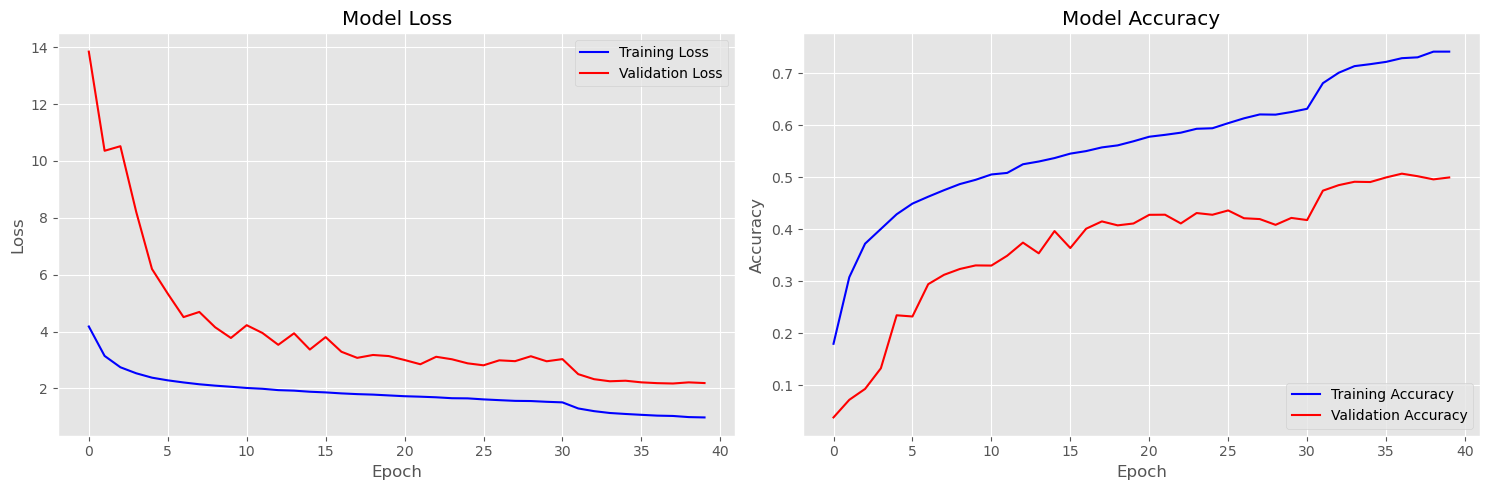

In [23]:
# Get number of epochs from history
n_epochs = len(H_MobileNet.history["loss"])

# Create figure with two subplots
plt.style.use("ggplot")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot Loss
ax1.plot(np.arange(0, n_epochs), H_MobileNet.history["loss"], label="Training Loss", color='blue')
ax1.plot(np.arange(0, n_epochs), H_MobileNet.history["val_loss"], label="Validation Loss", color='red')
ax1.set_title("Model Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend(loc='upper right')

# Plot Accuracy
ax2.plot(np.arange(0, n_epochs), H_MobileNet.history["accuracy"], label="Training Accuracy", color='blue')
ax2.plot(np.arange(0, n_epochs), H_MobileNet.history["val_accuracy"], label="Validation Accuracy", color='red')
ax2.set_title("Model Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend(loc='lower right')

# Adjust layout and display
plt.tight_layout()
plt.show()

### 3.1.4. Validación del modelo

In [24]:
print(classification_report(y_test.argmax(axis=1), model_MobileNet.predict(x_test).argmax(axis=1), target_names=labelNames))

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
               precision    recall  f1-score   support

        apple       0.91      0.49      0.64       100
aquarium_fish       0.71      0.22      0.34       100
         baby       0.26      0.30      0.28       100
         bear       0.21      0.07      0.11       100
       beaver       0.29      0.05      0.09       100
          bed       0.45      0.48      0.47       100
          bee       0.54      0.20      0.29       100
       beetle       0.71      0.17      0.27       100
      bicycle       0.45      0.68      0.54       100
       bottle       0.73      0.51      0.60       100
         bowl       0.14      0.26      0.18       100
          boy       0.41      0.12      0.19       100
       bridge       0.77      0.41      0.54       100
          bus       0.51      0.20      0.29       100
    butterfly       0.57      0.12      0.20       100
        camel       0.36      0.28      0.31       100
          can       0.

## 3.2. Modelo ResNet50

### 3.2.1. Arquitectura del modelo

### 3.2.2. Compilación del modelo

### 3.2.3. Entrenamiento del modelo

### 3.2.4. Validación del modelo

# 4. Estrategia 2: Modelo desde cero

## 4.1. Arquitectura del modelo

Para realizar una arquitectura desde 0, se crea un modelo compuesto por un base model de varias capas convolucionales que ayudarán al modelo a aprender y un top model flatten que termina la clasificación

In [ ]:
# Con data agumentation
model_base0 = Sequential([
    # Input Layer
    Input(shape=(x_train.shape[1], x_train.shape[2], x_train.shape[3])),

    # Convolutional Block 1
    BatchNormalization(),
    Conv2D(64, (3, 3), padding="same", activation='relu', kernel_regularizer=l2(0.0001)),
    BatchNormalization(),
    Conv2D(64, (3, 3), padding="same", activation='relu', kernel_regularizer=l2(0.0001)),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    # Convolutional Block 2
    BatchNormalization(),
    Conv2D(128, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(0.0001)),
    BatchNormalization(),
    Conv2D(128, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(0.0001)),
    MaxPooling2D((2, 2)),
    Dropout(0.35),

    # Convolutional Block 3
    BatchNormalization(),
    Conv2D(256, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(0.0001)),
    MaxPooling2D((2, 2)),
    BatchNormalization(),
    Conv2D(256, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(0.0001)),
    MaxPooling2D((2, 2)),
    Dropout(0.4),

    # Top Model
    Flatten(),
    Dense(256, activation='relu', kernel_regularizer=l2(0.0001)),
    BatchNormalization(),
    Dropout(0.5),
    
    # Salida
    Dense(100, activation='softmax')
])

Se usa input para optimizar el código y se añade el kernel_regularizer l2 para reducir overfiting

In [ ]:
model_base0.summary()

## 4.2. Compilamos el modelo

In [ ]:
model_base0.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=15),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', 
                                        factor=0.3,
                                        patience=5,
                                        min_lr=1e-7),
    tf.keras.callbacks.ModelCheckpoint('best_model.keras', 
                                     save_best_only=True)
]

## 4.3. Entrenamiento del modelo

In [ ]:
# Sin data augmentation
""""
print("[INFO]: Training the model...")
H = model_base0.fit(
    x_tr, y_tr,
    validation_data=(x_val, y_val),
    epochs=40,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)"""

In [ ]:
# Con data augmentation

train_generator = datagen.flow(
    x_train,
    y_train,
    batch_size=128,
    subset="training")
validation_generator = datagen.flow(
    x_train,
    y_train,
    batch_size=128,
    subset="validation")

print("[INFO]: Training the model...")
H = model_base0.fit(
    train_generator,
    validation_data = validation_generator,
    epochs=40,
    callbacks=callbacks,
    verbose=1
)

### 4.4. Muestreo de gráfica

In [ ]:
# Get number of epochs from history
n_epochs = len(H.history["loss"])

# Create figure with two subplots
plt.style.use("ggplot")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot Loss
ax1.plot(np.arange(0, n_epochs), H.history["loss"], label="Training Loss", color='blue')
ax1.plot(np.arange(0, n_epochs), H.history["val_loss"], label="Validation Loss", color='red')
ax1.set_title("Model Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend(loc='upper right')

# Plot Accuracy
ax2.plot(np.arange(0, n_epochs), H.history["accuracy"], label="Training Accuracy", color='blue')
ax2.plot(np.arange(0, n_epochs), H.history["val_accuracy"], label="Validation Accuracy", color='red')
ax2.set_title("Model Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend(loc='lower right')

# Adjust layout and display
plt.tight_layout()
plt.show()

## 4.4. Validación del modelo

Devolvemos la predicción a la clase correspondiente, para comprobar su eficacia

In [ ]:
print(classification_report(y_test.argmax(axis=1), model_base0.predict(x_test).argmax(axis=1), target_names=labelNames))

# 5. Comparación de modelos